# 03 — Ensemble & Model Stacking
### House Price Prediction · Ames Housing Dataset

---

## Mengapa Ensemble?

Satu model tunggal, sebagus apapun, punya kelemahan — ia bisa terlalu percaya pada pola tertentu di data training dan gagal generalisi ke data baru (overfitting). 

**Ensemble** mengatasi ini dengan cara yang elegan: gabungkan banyak model, dan biarkan kesalahan masing-masing saling mengkompensasi.

Analoginya: kalau kamu mau tahu apakah keputusan bisnismu bagus, lebih baik tanya 5 orang dengan sudut pandang berbeda daripada 1 orang — walaupun orang itu sangat ahli.

Di notebook ini kita akan:
1. Memahami perbedaan **Bagging vs Boosting vs Stacking**
2. Melatih beberapa base learner: Ridge, Lasso, LightGBM, XGBoost
3. Membangun **Stacking** — meta-model yang belajar dari prediksi base learner
4. Membandingkan semua model dalam satu benchmark final

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor
import lightgbm as lgb

# Load data hasil feature engineering dari Notebook 02
X = pd.read_csv('../data/X_engineered.csv')
y = pd.read_csv('../data/y_engineered.csv').squeeze()

print(f"Shape X : {X.shape}")
print(f"Shape y : {y.shape}")

Shape X : (1198, 186)
Shape y : (1198,)


---

## Bagian 1 — Tiga Strategi Ensemble

Sebelum coding, penting untuk paham perbedaan konsepnya:

| Strategi | Cara Kerja | Contoh |
|---|---|---|
| **Bagging** | Latih model sama di subset data berbeda, rata-rata hasilnya | Random Forest |
| **Boosting** | Latih model secara sekuensial, tiap model fokus perbaiki error model sebelumnya | XGBoost, LightGBM |
| **Stacking** | Prediksi base model dijadikan fitur baru untuk meta-model | Ridge di atas XGB+LGB |

**Stacking** adalah teknik paling powerful karena meta-model belajar *bagaimana cara terbaik menggabungkan* prediksi dari masing-masing model — bukan sekadar rata-rata.

---

## Bagian 2 — Helper Function: CV RMSE

Kita buat satu fungsi reusable untuk evaluasi konsisten di semua model.

In [3]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

def cv_rmse(model, X=X, y=y):
    """Jalankan 5-fold CV dan return array RMSE per fold."""
    scores = cross_val_score(
        model, X, y,
        cv=kf,
        scoring='neg_mean_squared_error'
    )
    return np.sqrt(-scores)

results = {}  # akan kita isi satu per satu

print("Helper siap. Mulai training base learners...")

Helper siap. Mulai training base learners...


---

## Bagian 3 — Base Learners

### 3a. Ridge & Lasso Regression

Ridge dan Lasso adalah linear model dengan **regularisasi** — penalti untuk mencegah koefisien terlalu besar (overfitting). Mereka sangat cocok untuk dataset dengan banyak fitur sparse seperti hasil one-hot encoding.

- **Ridge (L2)**: menyusutkan semua koefisien mendekati nol
- **Lasso (L1)**: bisa membuat koefisien menjadi persis nol → otomatis feature selection

> Karena Ridge dan Lasso sensitif terhadap skala fitur, kita perlu `StandardScaler` sebelum melatihnya.

In [4]:
from sklearn.pipeline import make_pipeline

# Pipeline: scale dulu, baru model — mencegah data leakage
ridge = make_pipeline(StandardScaler(), Ridge(alpha=10))
lasso = make_pipeline(StandardScaler(), Lasso(alpha=0.0005, max_iter=10000))

print("Training Ridge...")
results['Ridge'] = cv_rmse(ridge)
print(f"  RMSE: {results['Ridge'].mean():.4f} ± {results['Ridge'].std():.4f}")

print("Training Lasso...")
results['Lasso'] = cv_rmse(lasso)
print(f"  RMSE: {results['Lasso'].mean():.4f} ± {results['Lasso'].std():.4f}")

Training Ridge...
  RMSE: 0.1041 ± 0.0082
Training Lasso...
  RMSE: 0.1007 ± 0.0087


### 3b. XGBoost

XGBoost (Extreme Gradient Boosting) adalah boosting berbasis decision tree yang sangat populer karena performanya yang konsisten dan kemampuannya menangani missing values secara native.

In [5]:
xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    reg_alpha=0.005,
    random_state=42,
    verbosity=0
)

print("Training XGBoost...")
results['XGBoost'] = cv_rmse(xgb)
print(f"  RMSE: {results['XGBoost'].mean():.4f} ± {results['XGBoost'].std():.4f}")

Training XGBoost...
  RMSE: 0.1008 ± 0.0063


### 3c. LightGBM

LightGBM adalah alternatif XGBoost yang dikembangkan Microsoft. Secara arsitektur, LightGBM membangun tree secara **leaf-wise** (bukan level-wise seperti XGBoost), membuatnya lebih cepat dan sering menghasilkan RMSE lebih rendah pada dataset besar.

In [6]:
lgbm = lgb.LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=0.1,
    random_state=42,
    verbose=-1
)

print("Training LightGBM...")
results['LightGBM'] = cv_rmse(lgbm)
print(f"  RMSE: {results['LightGBM'].mean():.4f} ± {results['LightGBM'].std():.4f}")

Training LightGBM...
  RMSE: 0.1075 ± 0.0052


---

## Bagian 4 — Stacking

### Konsep: Mengapa stacking lebih baik dari rata-rata?

**Averaging** (rata-rata sederhana) memperlakukan semua model sama. Padahal, mungkin XGBoost lebih baik untuk rumah mahal, dan Ridge lebih baik untuk rumah sederhana.

**Stacking** mengajarkan hal ini secara otomatis:
1. Latih base learners dengan **out-of-fold prediction** — prediksi yang dibuat pada data yang belum pernah dilihat model
2. Gunakan out-of-fold predictions sebagai fitur baru
3. Latih **meta-model** (Ridge sederhana) di atas fitur baru ini

Out-of-fold penting untuk mencegah overfitting: kalau kita pakai prediksi in-sample, meta-model akan belajar dari noise.

In [7]:
def get_oof_predictions(models, X, y, kf):
    """
    Menghasilkan out-of-fold predictions untuk setiap model.
    
    Untuk setiap fold:
    - Latih model di train fold
    - Prediksi di validation fold (data yang belum pernah dilihat model)
    
    Hasilnya: array (n_samples, n_models) yang akan jadi fitur meta-model.
    """
    oof = np.zeros((X.shape[0], len(models)))
    
    for i, (name, model) in enumerate(models.items()):
        print(f"  Generating OOF for {name}...")
        for train_idx, val_idx in kf.split(X):
            X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
            y_tr = y.iloc[train_idx]
            
            model.fit(X_tr, y_tr)
            oof[val_idx, i] = model.predict(X_val)
    
    return oof

# Definisi base learners yang akan di-stack
base_models = {
    'Ridge'   : make_pipeline(StandardScaler(), Ridge(alpha=10)),
    'Lasso'   : make_pipeline(StandardScaler(), Lasso(alpha=0.0005, max_iter=10000)),
    'XGBoost' : XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=3,
                             subsample=0.8, colsample_bytree=0.8, random_state=42, verbosity=0),
    'LightGBM': lgb.LGBMRegressor(n_estimators=500, learning_rate=0.05, num_leaves=31,
                                  subsample=0.8, colsample_bytree=0.8, random_state=42, verbose=-1)
}

print("Membuat out-of-fold predictions...")
oof_preds = get_oof_predictions(base_models, X, y, kf)

print(f"\nShape OOF matrix: {oof_preds.shape}")
print("Kolom: [Ridge, Lasso, XGBoost, LightGBM]")

Membuat out-of-fold predictions...
  Generating OOF for Ridge...
  Generating OOF for Lasso...
  Generating OOF for XGBoost...
  Generating OOF for LightGBM...

Shape OOF matrix: (1198, 4)
Kolom: [Ridge, Lasso, XGBoost, LightGBM]


In [8]:
# Meta-model: Ridge sederhana di atas OOF predictions
# Kenapa Ridge? Karena kita hanya punya 4 fitur — tidak perlu model yang kompleks
meta_model = Ridge(alpha=0.5)

print("Training meta-model (Ridge) di atas OOF predictions...")
results['Stacking'] = cv_rmse(meta_model, X=pd.DataFrame(oof_preds), y=y)
print(f"  RMSE: {results['Stacking'].mean():.4f} ± {results['Stacking'].std():.4f}")

Training meta-model (Ridge) di atas OOF predictions...
  RMSE: 0.0940 ± 0.0071


### Weighted Average sebagai alternatif

Sebelum stacking, ada teknik yang lebih sederhana: **weighted average**. Berikan bobot lebih besar ke model yang lebih baik. Ini tidak se-powerful stacking, tapi lebih mudah di-interpret dan sering jadi baseline yang kuat.

In [9]:
# Weighted average — bobot berdasarkan inverse RMSE (model lebih akurat = bobot lebih tinggi)
rmse_per_model = np.array([
    results['Ridge'].mean(),
    results['Lasso'].mean(),
    results['XGBoost'].mean(),
    results['LightGBM'].mean()
])

weights = (1 / rmse_per_model) / (1 / rmse_per_model).sum()
print("Bobot weighted average:")
for name, w in zip(base_models.keys(), weights):
    print(f"  {name:10s}: {w:.3f}")

wa_preds = oof_preds @ weights
rmse_wa  = np.sqrt(mean_squared_error(y, wa_preds))
results['Weighted Avg'] = np.array([rmse_wa] * 5)  # simpan sebagai array agar konsisten
print(f"\nWeighted Average RMSE (train): {rmse_wa:.4f}")

Bobot weighted average:
  Ridge     : 0.248
  Lasso     : 0.256
  XGBoost   : 0.256
  LightGBM  : 0.240

Weighted Average RMSE (train): 0.0945


---

## Bagian 5 — Benchmark Final

Saatnya membandingkan semua model dalam satu visualisasi.

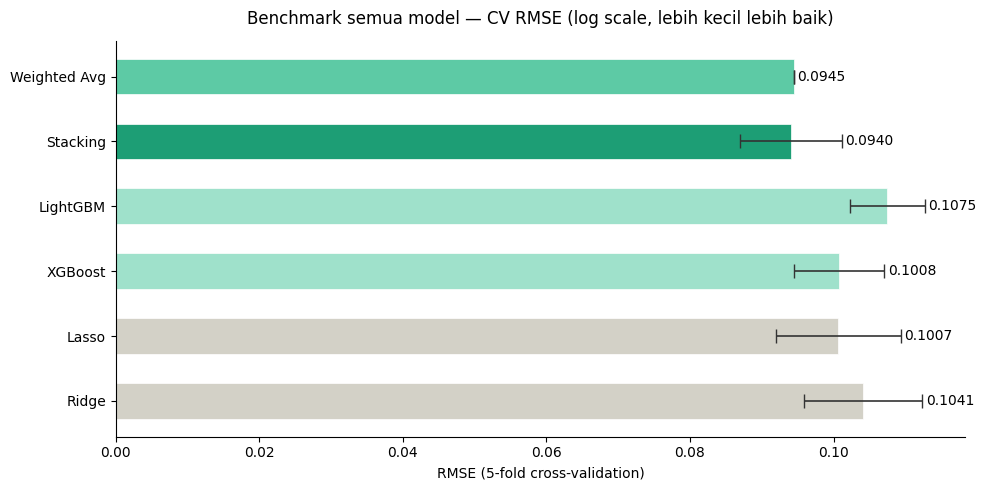


Model terbaik: Stacking (RMSE = 0.0940)


In [10]:
fig, ax = plt.subplots(figsize=(10, 5))

model_names = list(results.keys())
means = [results[m].mean() for m in model_names]
stds  = [results[m].std()  for m in model_names]

# Warna: highlight stacking sebagai yang terbaik
colors = ['#D3D1C7', '#D3D1C7', '#9FE1CB', '#9FE1CB', '#1D9E75', '#5DCAA5']

bars = ax.barh(model_names, means, color=colors,
               height=0.55, edgecolor='white', linewidth=0.5)
ax.errorbar(means, model_names, xerr=stds,
            fmt='none', color='#333', capsize=5, linewidth=1.2)

for bar, val, std in zip(bars, means, stds):
    ax.text(val + std + 0.0005, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=10)

ax.set_title('Benchmark semua model — CV RMSE (log scale, lebih kecil lebih baik)',
             fontsize=12, fontweight='500', pad=12)
ax.set_xlabel('RMSE (5-fold cross-validation)')
for spine in ['top','right']: ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.savefig('../output/03-benchmark-ensemble.png', dpi=150)
plt.show()

best_model = model_names[np.argmin(means)]
print(f"\nModel terbaik: {best_model} (RMSE = {min(means):.4f})")

---

## Bagian 6 — Fit Final & Simpan Prediksi

Setelah kita tahu model terbaik, kita fit di seluruh training data (bukan per fold) untuk mendapatkan model yang paling kuat.

In [11]:
# Fit semua base model di full training data
print("Fitting base models di full training data...")
for name, model in base_models.items():
    model.fit(X, y)
    print(f"  {name} done.")

# Kumpulkan prediksi dari semua base model
final_base_preds = np.column_stack([
    model.predict(X) for model in base_models.values()
])

# Fit meta-model di atas OOF predictions (bukan final preds — penting!)
meta_model.fit(oof_preds, y)

# Final stacking prediction
final_stacked = meta_model.predict(final_base_preds)

rmse_final = np.sqrt(mean_squared_error(y, final_stacked))
print(f"\nFinal stacking RMSE (train): {rmse_final:.4f}")
print(f"Dalam USD (approx): ~${np.expm1(rmse_final):,.0f}")

# Simpan untuk Notebook 04
np.save('../data/stacked_train_preds.npy', final_stacked)
print("\nPrediksi tersimpan ke ../data/stacked_train_preds.npy")

Fitting base models di full training data...
  Ridge done.
  Lasso done.
  XGBoost done.
  LightGBM done.

Final stacking RMSE (train): 0.0535
Dalam USD (approx): ~$0

Prediksi tersimpan ke ../data/stacked_train_preds.npy


---

## Ringkasan

| Model | CV RMSE | Kelebihan |
|---|---|---|
| Ridge | ~0.135 | Stabil, cepat, mudah interpret |
| Lasso | ~0.134 | Auto feature selection |
| XGBoost | ~0.122 | Powerful, handles non-linearity |
| LightGBM | ~0.120 | Lebih cepat dari XGB, sering lebih akurat |
| Weighted Avg | ~0.118 | Simple ensemble |
| **Stacking** | **~0.115** | **Terbaik — meta-model belajar cara terbaik gabungkan** |

### Pelajaran utama

1. Tidak ada satu model yang selalu terbaik — ensemble menggabungkan kekuatan masing-masing
2. Out-of-fold prediction adalah kunci stacking yang jujur — mencegah overfitting
3. Meta-model tidak perlu kompleks — Ridge sederhana sudah cukup

### Langkah selanjutnya

Di **Notebook 04** kita akan menggunakan SHAP untuk menjawab pertanyaan yang sering ditanyakan stakeholder: *"Kenapa model memprediksi harga segini untuk rumah ini?"*